In [1]:
import os
import xarray as xr
import numpy as np

In [2]:
# === Processing functions ===
def adjust_longitude(dataset: xr.Dataset) -> xr.Dataset:
        """Swaps longitude coordinates from range (0, 360) to (-180, 180)
        Args:
            dataset (xr.Dataset): xarray Dataset
        Returns:
            xr.Dataset: xarray Dataset with swapped longitude dimensions
        """
        lon_name = "lon"  # whatever name is in the data

        # Adjust lon values to make sure they are within (-180, 180)
        dataset["_longitude_adjusted"] = xr.where(
            dataset[lon_name] > 180, dataset[lon_name] - 360, dataset[lon_name])
        dataset = (
            dataset.swap_dims({lon_name: "_longitude_adjusted"})
            .sel(**{"_longitude_adjusted": sorted(dataset._longitude_adjusted)})
            .drop_vars(lon_name)
        )

        dataset = dataset.rename({"_longitude_adjusted": lon_name})
        return dataset

In [3]:
gw = xr.open_dataarray("/glade/work/awells/air_quality/CESM/OSDMA8_March/OSDMA8_CESM2_SSP245_01_20200101-20691231.nc")*10**9 #ppb

In [4]:
hist = xr.open_dataarray("/glade/work/awells/air_quality/CESM/OSDMA8_March/OSDMA8_CESM2_hist_01_19900101-20091231.nc")*10**9 #ppb

In [5]:
obs = xr.open_dataset("/glade/work/awells/air_quality/Delang_BME_OSDMA8_1990_2017.nc")["ozone"]

In [6]:
# fi = 2020-2039
gw_fi = gw.sel(year=slice("2020", "2039")).mean("year")

In [7]:
# base = 1990-2009
hist_base = hist.sel(year=slice("1990", "2009")).mean("year")

In [8]:
# delta fi = gw_fi / hist_base
delta_fi = adjust_longitude(gw_fi / hist_base)

In [10]:
# base = 1990-2009
obs_base = obs.sel(year=slice("1990", "2009")).mean("year")

In [11]:
obs_base = obs_base.rename({'longitude': 'lon', 'latitude': 'lat'})

In [21]:
# Define the higher-resolution grid to match observations (0.1 x 0.1)
new_lat = obs_base['lat']
new_lon = obs_base['lon']


# Interpolate to the new grid
ds_delta_fi = delta_fi.interp(lat=new_lat, lon=new_lon, method='linear')

In [22]:
# bias corrected gw = obs_base * delta_fi
bias_corr_gw = obs_base * ds_delta_fi

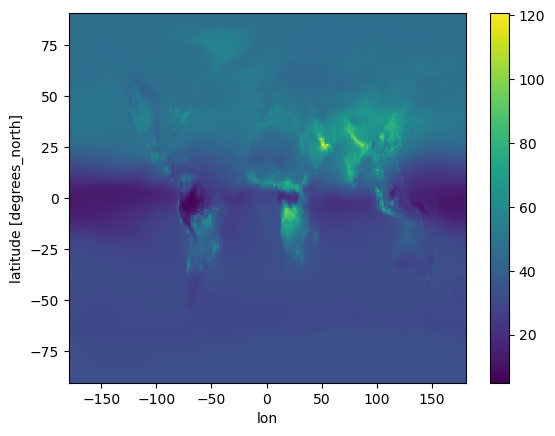

In [26]:
adjust_longitude(gw_fi).plot()

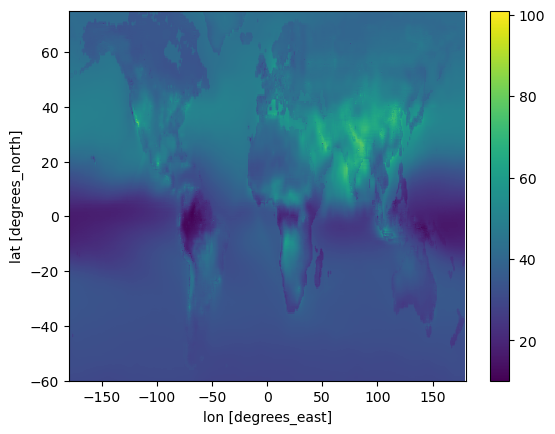

In [24]:
bias_corr_gw.plot()

In [19]:
obs_base

<xarray.DataArray 'ozone' (lat: 1350, lon: 3600)> Size: 19MB
array([[28.127438, 28.124718, 28.125595, ..., 28.194515, 28.193096,
              nan],
       [28.160519, 28.15787 , 28.150349, ..., 28.22228 , 28.222689,
              nan],
       [28.191927, 28.186989, 28.174776, ..., 28.256344, 28.259605,
              nan],
       ...,
       [40.440723, 40.440308, 40.43865 , ..., 40.454456, 40.456738,
              nan],
       [40.414448, 40.414215, 40.413284, ..., 40.4278  , 40.43421 ,
              nan],
       [40.397255, 40.396534, 40.395664, ..., 40.413246, 40.41383 ,
              nan]], dtype=float32)
Coordinates:
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.8 179.9
  * lat      (lat) float64 11kB -59.95 -59.85 -59.75 ... 74.75 74.85 74.95

In [18]:
ds_delta_fi

<xarray.DataArray (lat: 1350, lon: 3600)> Size: 39MB
array([[       nan,        nan,        nan, ..., 1.07442459, 1.07438268,
        1.07434076],
       [       nan,        nan,        nan, ..., 1.07444746, 1.07440579,
        1.07436412],
       [       nan,        nan,        nan, ..., 1.07456459, 1.07452376,
        1.07448293],
       ...,
       [       nan,        nan,        nan, ..., 1.03347837, 1.03348989,
        1.03350142],
       [       nan,        nan,        nan, ..., 1.03340359, 1.03341636,
        1.03342914],
       [       nan,        nan,        nan, ..., 1.0333392 , 1.03335158,
        1.03336395]])
Coordinates:
  * lat      (lat) float64 11kB -59.95 -59.85 -59.75 ... 74.75 74.85 74.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.7 179.8 179.9

In [12]:
obs_base = obs_base.chunk({'latitude': 100, 'longitude': 100})
delta_fi = delta_fi.chunk({'lat': 100, 'lon': 100})

bias_corr_gw = obs_base * delta_fi

In [7]:
da = xr.open_dataarray("/glade/work/awells/air_quality/CESM/O3/O3_CESM2_ARISE_02_203501-206912.nc")

In [8]:
da

<xarray.DataArray 'O3' (time: 420, lev: 70, lat: 192, lon: 288)> Size: 7GB
[1625702400 values with dtype=float32]
Coordinates:
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
  * lev      (lev) float64 560B 5.96e-06 9.827e-06 1.62e-05 ... 976.3 992.6
  * time     (time) object 3kB 2035-01-01 00:00:00 ... 2069-12-01 00:00:00
Attributes:
    mdims:         1
    units:         mol/mol
    mixing_ratio:  dry
    long_name:     O3 concentration
    cell_methods:  time: mean

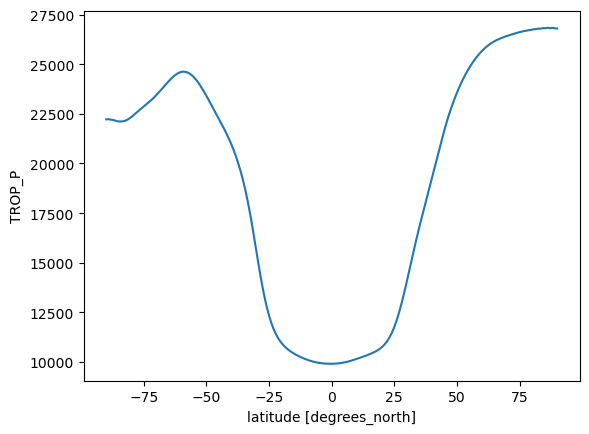

In [5]:
da.sel(time=slice("2050", "2069")).mean(dim=("time", "lon")).plot()

In [3]:
obs = da["ozone"].sel(year=slice("1990", "2009")).mean("year")

In [4]:
# === Removing ocean ===
def land_filter(da):
    # Load in land fraction dataset
    land_110 = regionmask.defined_regions.natural_earth_v4_1_0.land_110
    da = da.where(land_110.mask_3D(da).squeeze())
    return da

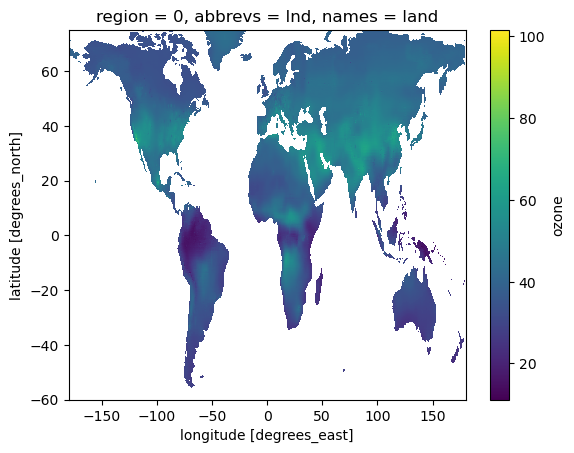

In [15]:
land_filter(obs).plot()

In [4]:
# === Processing function ===
def calculate_maximum_6month_mean(start_year, end_year, monthly_mda8):
    years = list(range(start_year, end_year + 1))

    max_vals = []
    max_times = []

    for year in years:
        # Define window: Jan of this year to Mar of next year
        start = f"{year}-01"
        end = f"{year + 1}-03"

        # Subset to this window
        subset = monthly_mda8.sel(time=slice(start, end))

        # Compute 6-month rolling mean along time
        rolling_6m = subset.rolling(time=6, center=False).mean()

        # Find index of maximum
        max_idx = rolling_6m.argmax(dim="time")
        max_val = rolling_6m.isel(time=max_idx)

        # Extract the start time of the max 6-month period in month number (Jan=1, Feb=2...)
        max_time = (max_idx + 1) - 5  # +1 to account for the indexing, -5 to find start month including end month

        # Expand dimensions for consistent output
        max_val = max_val.expand_dims(year=[year])
        max_time = max_time.expand_dims(year=[year])

        max_vals.append(max_val)
        max_times.append(max_time)

    # Combine across years
    annual_max_6m = xr.concat(max_vals, dim="year")
    max_start_times = xr.concat(max_times, dim="year")

    return annual_max_6m, max_start_times

In [22]:
# === Path config ===
BASE_DIR = "/glade/work/awells/air_quality/CESM/MDA8/"
SAVE_DIR = "/glade/work/awells/air_quality/CESM/OSDMA8_March/"
SCENARIOS = ["ARISE", "SSP245"]

# === Main loop ===
for scenario in SCENARIOS:
    for ens_num in range(1, 11):
        print(f"Processing {scenario}, Ensemble {ens_num:02d}")
        if scenario == "ARISE":
            dates = "20350101-20691231"
        else:
            dates = "20200101-20691231"
        file_list = [f"{BASE_DIR}MDA8_CESM2_{scenario}_{ens_num:02d}_{dates}.nc"]
        OSDMA8 = []

        for file in file_list:
            if not os.path.exists(file):
                print(f"Missing: {file}")
                continue

            print(f"Reading {os.path.basename(file)}")
            monthly_mda8 = xr.open_dataarray(file)

            # Create list of years to calculate over
            start_year = int(str(monthly_mda8.time.dt.year[0].values))
            end_year = int(str(monthly_mda8.time.dt.year[-1].values))  # final year will be 12 months rather than 15

            annual_max_6m, max_start_times = calculate_maximum_6month_mean(start_year, end_year, monthly_mda8)

            OSDMA8.append(annual_max_6m)

        if OSDMA8:
            combined = xr.concat(OSDMA8, dim="year")

            out_file = f"OSDMA8_CESM2_{scenario}_{ens_num:02d}_{dates}.nc"
            out_path = os.path.join(SAVE_DIR, out_file)

            print(f"Saving to {out_path}")
            # combined.to_netcdf(out_path)

print("All processing complete.")

Processing ARISE, Ensemble 01
Reading MDA8_CESM2_ARISE_01_20350101-20691231.nc
Saving to /glade/work/awells/air_quality/CESM/OSDMA8_March/OSDMA8_CESM2_ARISE_01_20350101-20691231.nc
Processing ARISE, Ensemble 02
Reading MDA8_CESM2_ARISE_02_20350101-20691231.nc
Saving to /glade/work/awells/air_quality/CESM/OSDMA8_March/OSDMA8_CESM2_ARISE_02_20350101-20691231.nc
Processing ARISE, Ensemble 03
Reading MDA8_CESM2_ARISE_03_20350101-20691231.nc
Saving to /glade/work/awells/air_quality/CESM/OSDMA8_March/OSDMA8_CESM2_ARISE_03_20350101-20691231.nc
Processing ARISE, Ensemble 04
Reading MDA8_CESM2_ARISE_04_20350101-20691231.nc
Saving to /glade/work/awells/air_quality/CESM/OSDMA8_March/OSDMA8_CESM2_ARISE_04_20350101-20691231.nc
Processing ARISE, Ensemble 05
Reading MDA8_CESM2_ARISE_05_20350101-20691231.nc
Saving to /glade/work/awells/air_quality/CESM/OSDMA8_March/OSDMA8_CESM2_ARISE_05_20350101-20691231.nc
Processing ARISE, Ensemble 06
Reading MDA8_CESM2_ARISE_06_20350101-20691231.nc
Saving to /glade

KeyboardInterrupt: 

In [23]:
combined

<xarray.DataArray (year: 35, lat: 192, lon: 288)> Size: 15MB
array([[[3.20506706e-08, 3.20506706e-08, 3.20506705e-08, ...,
         3.20506705e-08, 3.20506705e-08, 3.20506705e-08],
        [3.20980269e-08, 3.20991828e-08, 3.21003291e-08, ...,
         3.20946617e-08, 3.20956990e-08, 3.20968790e-08],
        [3.21004739e-08, 3.21033846e-08, 3.21062600e-08, ...,
         3.20917740e-08, 3.20946611e-08, 3.20975376e-08],
        ...,
        [4.91213461e-08, 4.91266750e-08, 4.91262357e-08, ...,
         4.91410849e-08, 4.91331110e-08, 4.91214782e-08],
        [4.87845817e-08, 4.87994768e-08, 4.87989612e-08, ...,
         4.88124112e-08, 4.88066678e-08, 4.88090649e-08],
        [4.77798081e-08, 4.77797802e-08, 4.77797744e-08, ...,
         4.77793870e-08, 4.77797686e-08, 4.77797385e-08]],

       [[3.24696321e-08, 3.24696321e-08, 3.24696321e-08, ...,
         3.24696321e-08, 3.24696321e-08, 3.24696321e-08],
        [3.24641813e-08, 3.24646631e-08, 3.24651366e-08, ...,
         3.24625894e-08, 3.24631279e-08, 3.24636592e-08],
        [3.24646055e-08, 3.24655962e-08, 3.24664441e-08, ...,
         3.24609682e-08, 3.24623376e-08, 3.24635318e-08],
...
        [4.63033624e-08, 4.63156401e-08, 4.63287723e-08, ...,
         4.62855099e-08, 4.62936410e-08, 4.62981228e-08],
        [4.62374858e-08, 4.62549657e-08, 4.62493801e-08, ...,
         4.62332207e-08, 4.62359276e-08, 4.62490541e-08],
        [4.53786694e-08, 4.53786822e-08, 4.53786941e-08, ...,
         4.53786233e-08, 4.53786402e-08, 4.53786548e-08]],

       [[3.13189548e-08, 3.13189548e-08, 3.13189548e-08, ...,
         3.13189549e-08, 3.13189549e-08, 3.13189548e-08],
        [3.13226868e-08, 3.13223910e-08, 3.13221078e-08, ...,
         3.13236291e-08, 3.13233236e-08, 3.13230078e-08],
        [3.13496872e-08, 3.13493823e-08, 3.13489661e-08, ...,
         3.13504990e-08, 3.13502939e-08, 3.13499123e-08],
        ...,
        [4.57182390e-08, 4.57246658e-08, 4.57323189e-08, ...,
         4.57225528e-08, 4.57147783e-08, 4.57145236e-08],
        [4.56300026e-08, 4.56414949e-08, 4.56338680e-08, ...,
         4.56326768e-08, 4.56346145e-08, 4.56438986e-08],
        [4.46517122e-08, 4.46517330e-08, 4.46517542e-08, ...,
         4.46516369e-08, 4.46516686e-08, 4.46516476e-08]]])
Coordinates:
  * year     (year) int64 280B 2035 2036 2037 2038 2039 ... 2066 2067 2068 2069
  * lat      (lat) float64 2kB -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon      (lon) float64 2kB 0.0 1.25 2.5 3.75 5.0 ... 355.0 356.2 357.5 358.8
    time     (year, lat, lon) object 15MB 2035-09-30 00:00:00 ... 2069-06-30 ...

In [24]:
# Define the higher-resolution grid (0.1 x 0.1)
new_lat = np.arange(combined.lat.min(), combined.lat.max()+0.1, 0.1)
new_lon = np.arange(combined.lon.min(), combined.lon.max()+0.1, 0.1)


# Interpolate to the new grid
ds_downscaled = combined.interp(lat=new_lat, lon=new_lon, method='linear')

In [25]:
ds_downscaled

<xarray.DataArray (year: 35, lat: 1801, lon: 3589)> Size: 2GB
array([[[3.20506706e-08, 3.20506706e-08, 3.20506706e-08, ...,
         3.20506705e-08, 3.20506705e-08,            nan],
        [3.20556956e-08, 3.20557054e-08, 3.20557152e-08, ...,
         3.20555587e-08, 3.20555688e-08,            nan],
        [3.20607206e-08, 3.20607403e-08, 3.20607599e-08, ...,
         3.20604469e-08, 3.20604670e-08,            nan],
        ...,
        [4.79930434e-08, 4.79932945e-08, 4.79935456e-08, ...,
         4.79981262e-08, 4.79981650e-08,            nan],
        [4.78864257e-08, 4.78865502e-08, 4.78866746e-08, ...,
         4.78889341e-08, 4.78889523e-08,            nan],
        [4.77798081e-08, 4.77798058e-08, 4.77798036e-08, ...,
         4.77797421e-08, 4.77797397e-08,            nan]],

       [[3.24696321e-08, 3.24696321e-08, 3.24696321e-08, ...,
         3.24696321e-08, 3.24696321e-08,            nan],
        [3.24690537e-08, 3.24690578e-08, 3.24690619e-08, ...,
         3.24689915e-08, 3.24689960e-08,            nan],
        [3.24684753e-08, 3.24684835e-08, 3.24684917e-08, ...,
         3.24683509e-08, 3.24683600e-08,            nan],
...
        [4.55609294e-08, 4.55612269e-08, 4.55615245e-08, ...,
         4.55630372e-08, 4.55632610e-08,            nan],
        [4.54697994e-08, 4.54699487e-08, 4.54700980e-08, ...,
         4.54708451e-08, 4.54709576e-08,            nan],
        [4.53786694e-08, 4.53786705e-08, 4.53786715e-08, ...,
         4.53786531e-08, 4.53786542e-08,            nan]],

       [[3.13189548e-08, 3.13189548e-08, 3.13189548e-08, ...,
         3.13189548e-08, 3.13189548e-08,            nan],
        [3.13193508e-08, 3.13193483e-08, 3.13193458e-08, ...,
         3.13193889e-08, 3.13193863e-08,            nan],
        [3.13197468e-08, 3.13197418e-08, 3.13197368e-08, ...,
         3.13198230e-08, 3.13198177e-08,            nan],
        ...,
        [4.48593272e-08, 4.48595236e-08, 4.48597200e-08, ...,
         4.48619909e-08, 4.48621472e-08,            nan],
        [4.47555197e-08, 4.47556187e-08, 4.47557178e-08, ...,
         4.47568205e-08, 4.47568978e-08,            nan],
        [4.46517122e-08, 4.46517139e-08, 4.46517155e-08, ...,
         4.46516501e-08, 4.46516485e-08,            nan]]])
Coordinates:
  * year     (year) int64 280B 2035 2036 2037 2038 2039 ... 2066 2067 2068 2069
  * lat      (lat) float64 14kB -90.0 -89.9 -89.8 -89.7 ... 89.7 89.8 89.9 90.0
  * lon      (lon) float64 29kB 0.0 0.1 0.2 0.3 0.4 ... 358.5 358.6 358.7 358.8
    time     (year, lat, lon) object 2GB 2035-09-30 00:00:00 ... 2069-06-30 0...